## Data Processing

In [ ]:
import pandas as pd

df = pd.read_csv("final_dataset.csv", dtype={"postId": str, "facebookId_post": str}, low_memory=False)
df = df.drop_duplicates()
df.fillna({'likes': 0, 'comments': 0, 'shares': 0, 'viewsCount': 0, 'Comment_Text': ''}, inplace=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 45668 entries, 0 to 45670
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   postId             45668 non-null  object        
 1   pageName           45668 non-null  object        
 2   url                45668 non-null  object        
 3   time               45668 non-null  object        
 4   timestamp          45668 non-null  datetime64[ns]
 5   text               45556 non-null  object        
 6   likes              45668 non-null  int64         
 7   comments           45668 non-null  float64       
 8   shares             45668 non-null  int64         
 9   topReactionsCount  45668 non-null  int64         
 10  facebookId_post    45668 non-null  object        
 11  media              35074 non-null  object        
 12  isVideo            3091 non-null   float64       
 13  viewsCount         45668 non-null  float64       
 14  commentUrl 

In [ ]:
df['comments'] = df['comments'].astype(int)

df['isVideo'].fillna(0, inplace=True)
df['isVideo'] = df['isVideo'].astype(int)

df['likesCount'] = pd.to_numeric(df['likesCount'], errors='coerce').fillna(0).astype(int)

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 45668 entries, 0 to 45670
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   postId             45668 non-null  object        
 1   pageName           45668 non-null  object        
 2   url                45668 non-null  object        
 3   time               45668 non-null  object        
 4   timestamp          45668 non-null  datetime64[ns]
 5   text               45556 non-null  object        
 6   likes              45668 non-null  int64         
 7   comments           45668 non-null  int64         
 8   shares             45668 non-null  int64         
 9   topReactionsCount  45668 non-null  int64         
 10  facebookId_post    45668 non-null  object        
 11  media              35074 non-null  object        
 12  isVideo            45668 non-null  int64         
 13  viewsCount         45668 non-null  float64       
 14  commentUrl 

C:\Users\DELL\AppData\Local\Temp\ipykernel_11496\4028936208.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['isVideo'].fillna(0, inplace=True)


In [ ]:
df = df.copy()
df['isVideo'] = df['isVideo'].fillna(0).astype(int)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 45668 entries, 0 to 45670
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   postId             45668 non-null  object        
 1   pageName           45668 non-null  object        
 2   url                45668 non-null  object        
 3   time               45668 non-null  object        
 4   timestamp          45668 non-null  datetime64[ns]
 5   text               45556 non-null  object        
 6   likes              45668 non-null  int64         
 7   comments           45668 non-null  int64         
 8   shares             45668 non-null  int64         
 9   topReactionsCount  45668 non-null  int64         
 10  facebookId_post    45668 non-null  object        
 11  media              35074 non-null  object        
 12  isVideo            45668 non-null  int64         
 13  viewsCount         45668 non-null  float64       
 14  commentUrl 

In [ ]:
import numpy as np
cols_to_log = ['likes', 'comments', 'shares', 'topReactionsCount', 'viewsCount']
for col in cols_to_log:
    df[f'log_{col}'] = np.log1p(df[col])

print(df[[col] + [f'log_{col}']].head() for col in cols_to_log)
df.head()

<generator object <genexpr> at 0x0000020AA54C6120>


,postId,pageName,url,time,timestamp,text,likes,comments,shares,topReactionsCount,...,commentUrl,commentId,date,Comment_Text,likesCount,log_likes,log_comments,log_shares,log_topReactionsCount,log_viewsCount
0,625312393573422,DookkiVietnam,https://www.facebook.com/DookkiVietnam/posts/p...,2025-03-02T03:56:06.000Z,2025-03-02 03:56:06,🐔,313,38,4,4,...,https://www.facebook.com/DookkiVietnam/posts/p...,Y29tbWVudDo2MjUzMTIzOTM1NzM0MjJfNjIzNDM1OTY2OT...,2025-03-02T04:07:59.000Z,Mỗi ngày 1 con gà hơ hơ ...,6,5.749393,3.663562,1.609438,1.609438,0.0
1,625312393573422,DookkiVietnam,https://www.facebook.com/DookkiVietnam/posts/p...,2025-03-02T03:56:06.000Z,2025-03-02 03:56:06,🐔,313,38,4,4,...,https://www.facebook.com/DookkiVietnam/posts/p...,Y29tbWVudDo2MjUzMTIzOTM1NzM0MjJfMTMxNTM5MTA0Mz...,2025-03-02T04:02:16.000Z,đầu gà chiên à shop=)),2,5.749393,3.663562,1.609438,1.609438,0.0
2,625312393573422,DookkiVietnam,https://www.facebook.com/DookkiVietnam/posts/p...,2025-03-02T03:56:06.000Z,2025-03-02 03:56:06,🐔,313,38,4,4,...,https://www.facebook.com/DookkiVietnam/posts/p...,Y29tbWVudDo2MjUzMTIzOTM1NzM0MjJfMTAxNDk4NjQzNz...,2025-03-02T05:10:58.000Z,Em sẽ ko nói là nãy ngồi ăn ở Vincom phạm hùn...,0,5.749393,3.663562,1.609438,1.609438,0.0
3,625312393573422,DookkiVietnam,https://www.facebook.com/DookkiVietnam/posts/p...,2025-03-02T03:56:06.000Z,2025-03-02 03:56:06,🐔,313,38,4,4,...,https://www.facebook.com/DookkiVietnam/posts/p...,Y29tbWVudDo2MjUzMTIzOTM1NzM0MjJfMjE0MTUzNDE1Nj...,2025-03-02T03:59:07.000Z,Cái dì nữa dợ. Đầu gà chiên? Mào gà sốt?,3,5.749393,3.663562,1.609438,1.609438,0.0
4,625312393573422,DookkiVietnam,https://www.facebook.com/DookkiVietnam/posts/p...,2025-03-02T03:56:06.000Z,2025-03-02 03:56:06,🐔,313,38,4,4,...,https://www.facebook.com/DookkiVietnam/posts/p...,Y29tbWVudDo2MjUzMTIzOTM1NzM0MjJfMTAzMjA1NzAwNT...,2025-03-02T05:07:13.000Z,Sale sủng gì chưa người đẹp,1,5.749393,3.663562,1.609438,1.609438,0.0


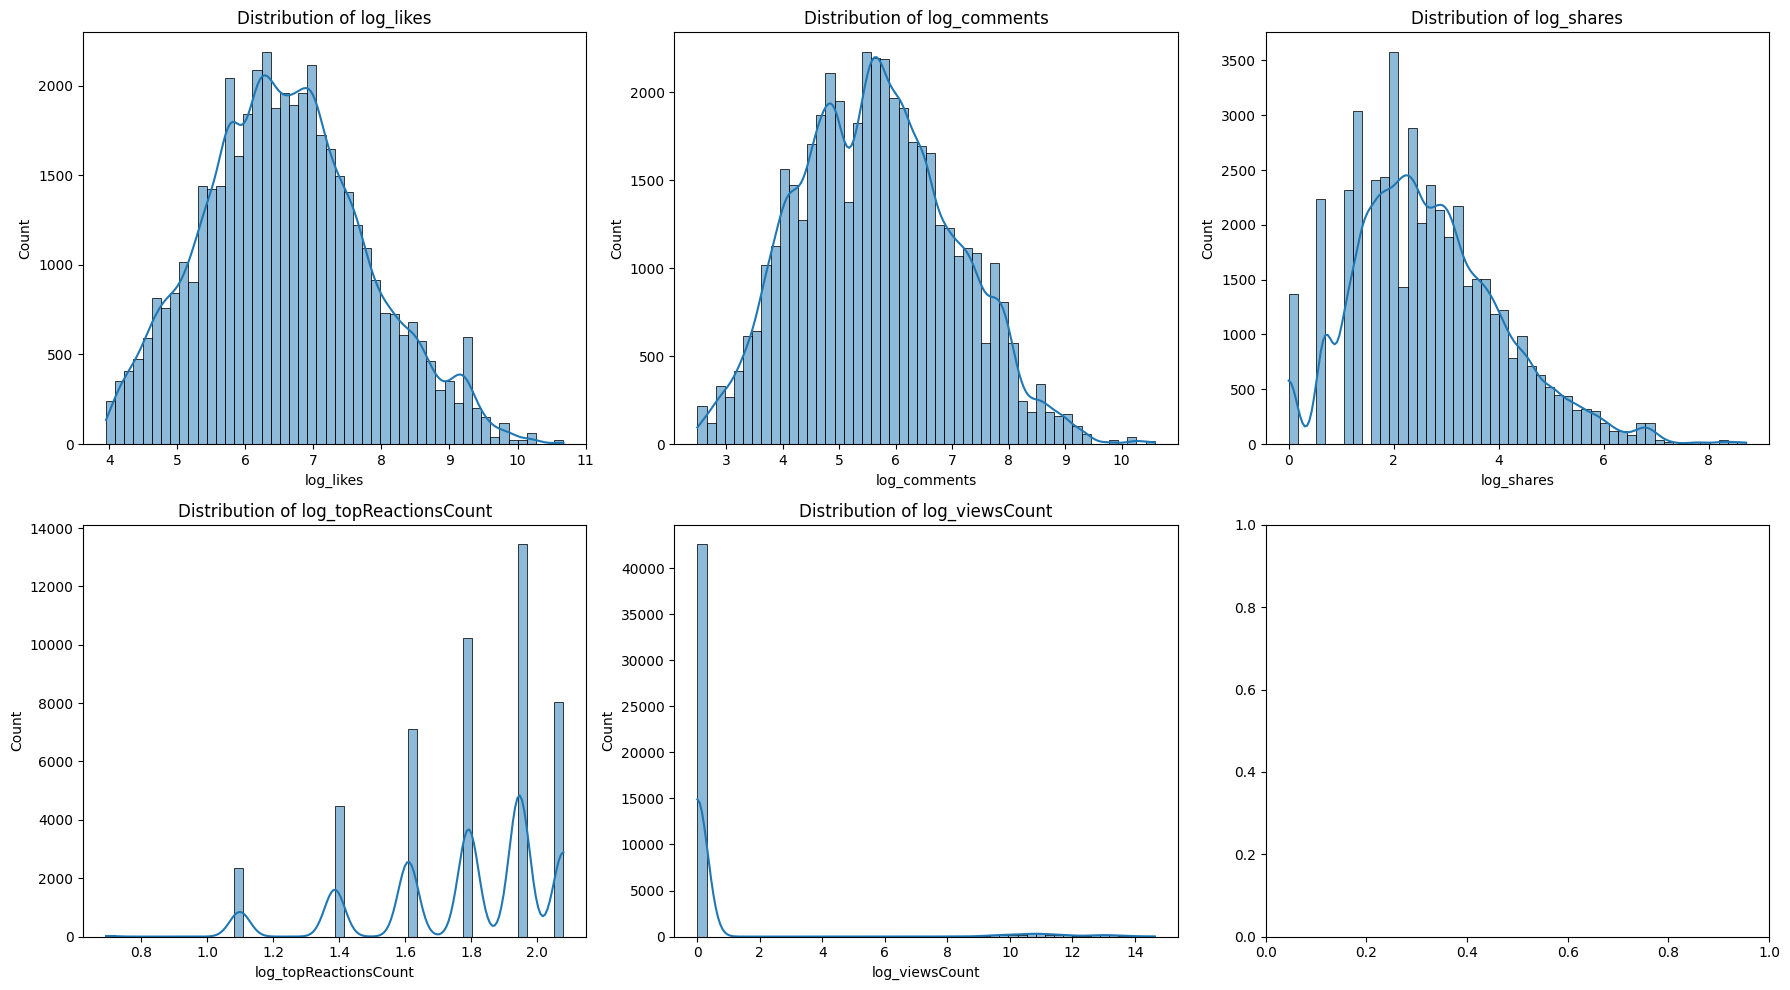

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cols_to_visualize = ['log_likes', 'log_comments', 'log_shares', 'log_topReactionsCount', 'log_viewsCount']
for i, col in enumerate(cols_to_visualize):
    sns.histplot(df[col], bins=50, kde=True, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [ ]:
df[df['viewsCount'] == 0]['isVideo'].value_counts()

isVideo
0    42577
Name: count, dtype: int64

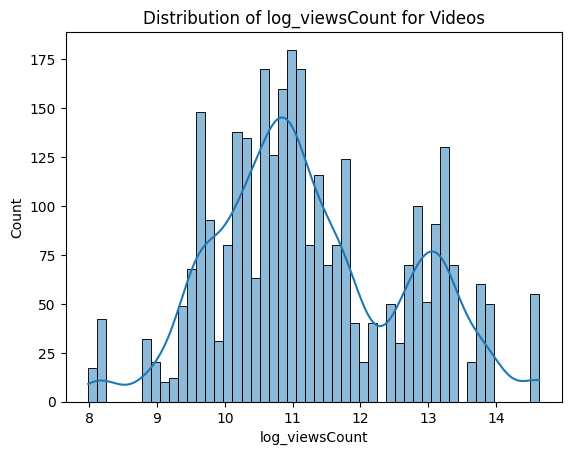

In [ ]:
df_videos = df[df['isVideo'] == 1]
sns.histplot(df_videos['log_viewsCount'], bins=50, kde=True)
plt.title('Distribution of log_viewsCount for Videos')
plt.show()

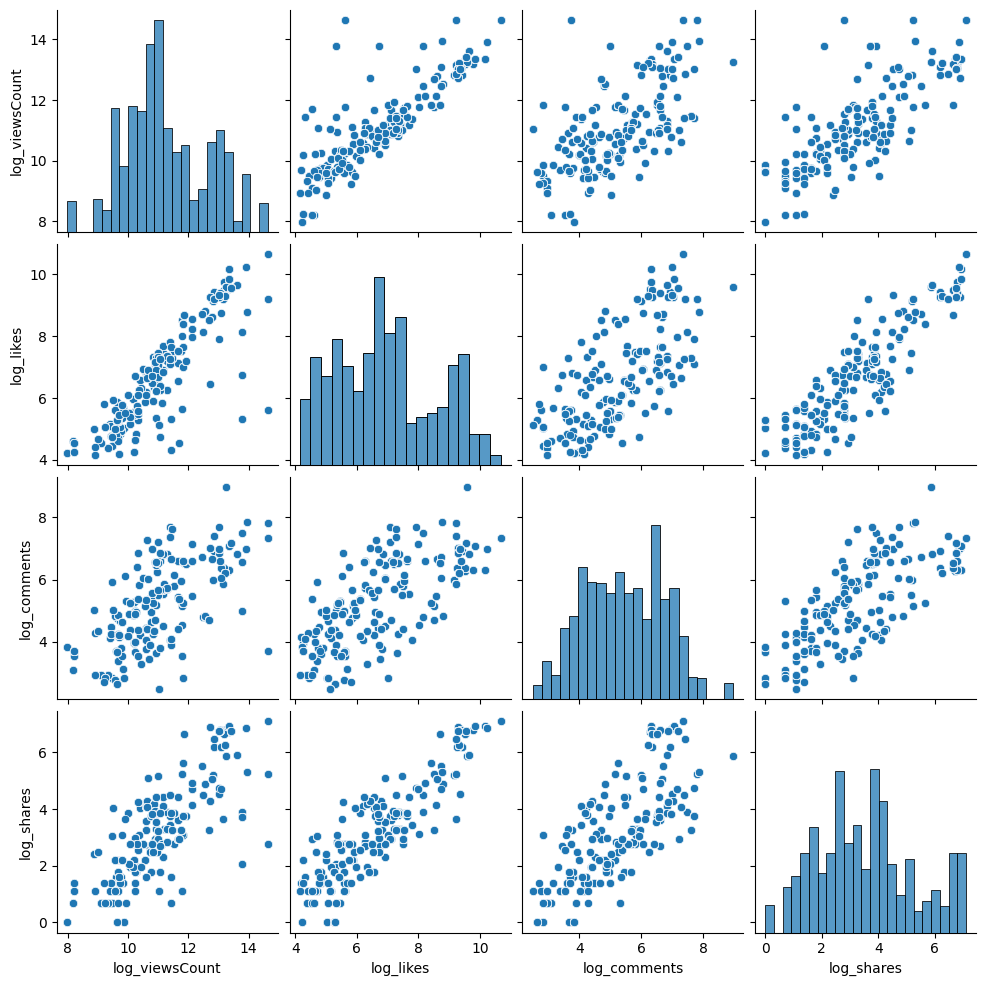

In [ ]:
sns.pairplot(df_videos, vars=['log_viewsCount', 'log_likes', 'log_comments', 'log_shares'])
plt.show()

In [ ]:
df_videos[['log_viewsCount', 'log_likes', 'log_comments', 'log_shares']].corr()

,log_viewsCount,log_likes,log_comments,log_shares
log_viewsCount,1.000000,0.841632,0.634516,0.768191
log_likes,0.841632,1.000000,0.658952,0.889637
log_comments,0.634516,0.658952,1.000000,0.686456
log_shares,0.768191,0.889637,0.686456,1.000000


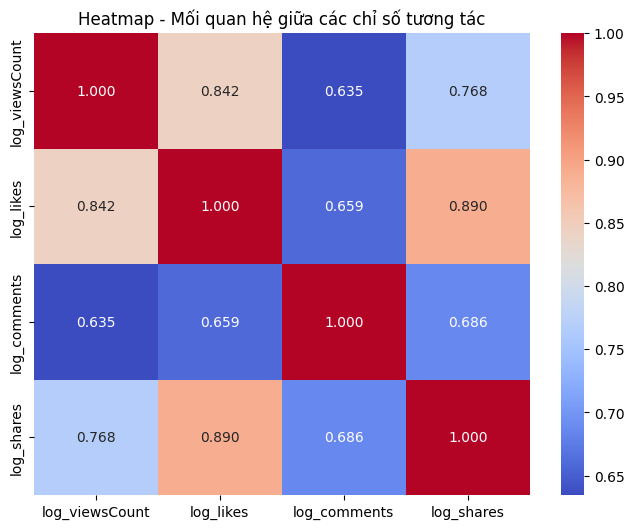

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df_videos[['log_viewsCount', 'log_likes', 'log_comments', 'log_shares']].corr(), annot=True, cmap='coolwarm', fmt='.3f')
plt.title("Heatmap - Mối quan hệ giữa các chỉ số tương tác")
plt.show()

In [ ]:
df_videos = df_videos.copy()

df_videos['like_per_view'] = df_videos['log_likes'] / df_videos['log_viewsCount']
df_videos['comment_per_view'] = df_videos['log_comments'] / df_videos['log_viewsCount']
df_videos['share_per_view'] = df_videos['log_shares'] / df_videos['log_viewsCount']
df_videos['share_per_like'] = df_videos['log_shares'] / df_videos['log_likes']

df_videos['total_interaction'] = df_videos['log_likes'] + df_videos['log_comments'] + df_videos['log_shares']
df_videos['comment_per_like'] = df_videos['log_comments'] / df_videos['log_likes']

In [ ]:
df_videos['interaction_per_view'] = df_videos['total_interaction'] / df_videos['log_viewsCount']
df_videos['virality_score'] = (df_videos['log_shares'] / df_videos['log_viewsCount']) * 100
df_videos['comment_ratio'] = df_videos['log_comments'] / df_videos['total_interaction']
df_videos['share_ratio'] = df_videos['log_shares'] / df_videos['total_interaction']
df_videos['like_ratio'] = df_videos['log_likes'] / df_videos['total_interaction']

In [ ]:
df_videos[['interaction_per_view', 'virality_score', 'comment_ratio', 'share_ratio', 'like_ratio']].describe()

,interaction_per_view,virality_score,comment_ratio,share_ratio,like_ratio
count,3091.000000,3091.000000,3091.000000,3091.000000,3091.000000
mean,1.395638,30.531747,0.347559,0.209780,0.442661
std,0.253555,12.769277,0.051498,0.062507,0.048463
min,0.789327,0.000000,0.219057,0.000000,0.333661
25%,1.230711,20.814021,0.298690,0.171389,0.410853
50%,1.413887,30.179940,0.359917,0.214458,0.431556
75%,1.605253,38.973354,0.387005,0.257792,0.467132
max,1.846031,56.119451,0.476594,0.304001,0.667094


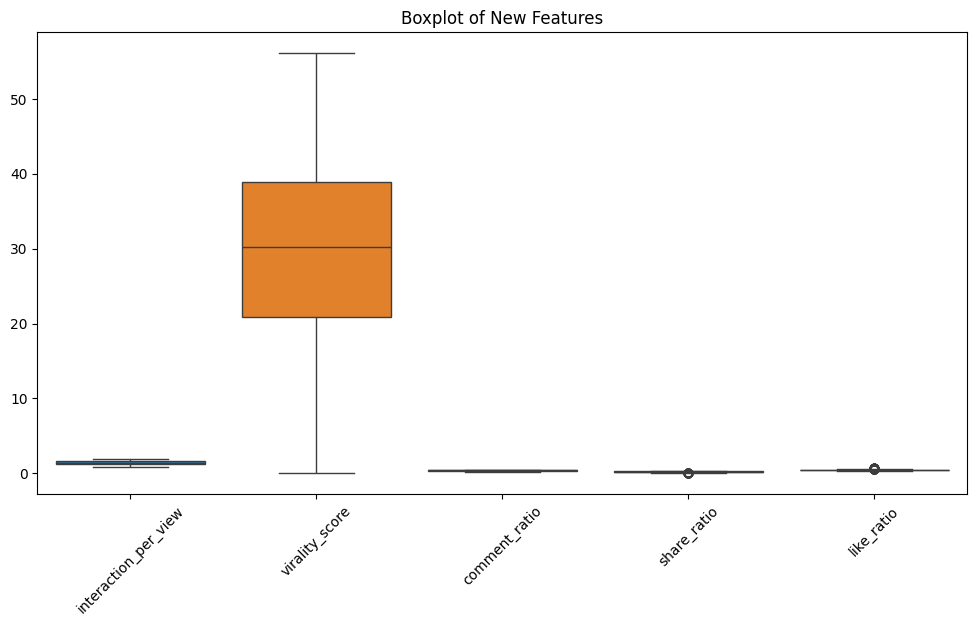

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['interaction_per_view', 'virality_score', 'comment_ratio', 'share_ratio', 'like_ratio']
plt.figure(figsize=(12,6))
sns.boxplot(data=df_videos[features])
plt.title("Boxplot of New Features")
plt.xticks(rotation=45)
plt.show()

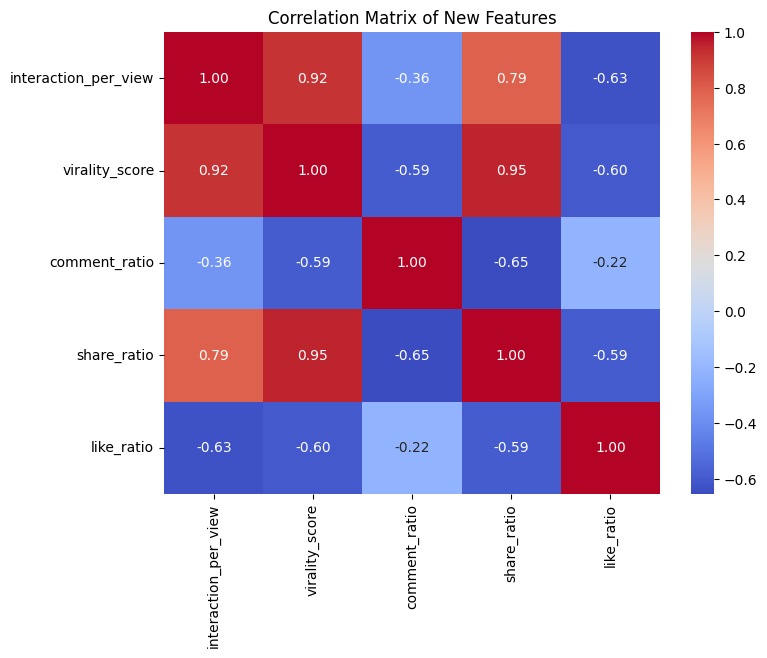

In [ ]:
corr_matrix = df_videos[features].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of New Features")
plt.show()

## Phân tích hiệu suất

In [ ]:
df["Engagement_Score"] = df["likes"] + df["comments"] * 2 + df["shares"] * 3 + df["viewsCount"] * 0.5

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['month'] = df['timestamp'].dt.to_period('M')  # YYYY-MM
df['quarter'] = df['timestamp'].dt.to_period('Q')  # YYYYQX
df_monthly = df.groupby('month')['Engagement_Score'].sum().reset_index()
df_quarterly = df.groupby('quarter')['Engagement_Score'].sum().reset_index()

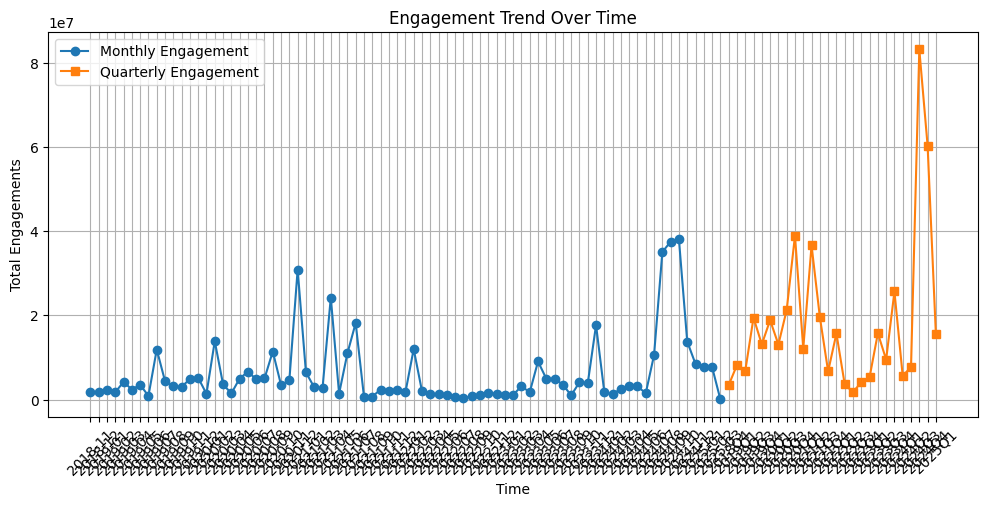

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_monthly['month'].astype(str), df_monthly['Engagement_Score'], marker='o', label='Monthly Engagement')
plt.plot(df_quarterly['quarter'].astype(str), df_quarterly['Engagement_Score'], marker='s', label='Quarterly Engagement')
plt.xticks(rotation=45)
plt.xlabel("Time")
plt.ylabel("Total Engagements")
plt.title("Engagement Trend Over Time")
plt.legend()
plt.grid()
plt.show()

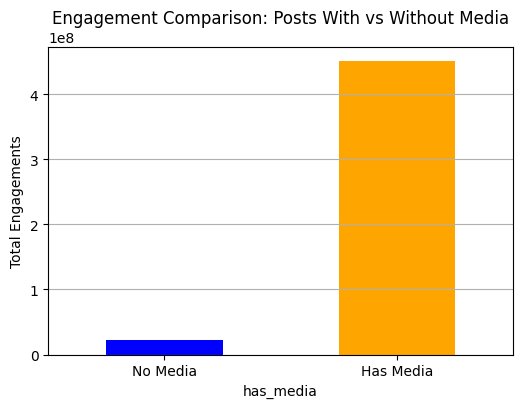

In [ ]:
df['has_media'] = df['media'].notnull()

engagement_by_media = df.groupby('has_media')['Engagement_Score'].sum()

plt.figure(figsize=(6,4))
engagement_by_media.plot(kind='bar', color=['blue', 'orange'])
plt.xticks(ticks=[0,1], labels=['No Media', 'Has Media'], rotation=0)
plt.ylabel("Total Engagements")
plt.title("Engagement Comparison: Posts With vs Without Media")
plt.grid(axis='y')
plt.show()


In [ ]:
df_posts = df.drop(columns=['commentUrl', 'commentId', 'Comment_Text', 'likesCount'], errors='ignore')

df_posts = df_posts.drop_duplicates(subset=['postId'])

print(f"Số lượng bài đăng sau khi lọc: {df_posts['postId'].nunique()}")
print(df_posts.head())

Số lượng bài đăng sau khi lọc: 2464
              postId       pageName  \
0    625312393573422  DookkiVietnam   
30   624546570316671  DookkiVietnam   
60   623900560381272  DookkiVietnam   
77   623757880395540  DookkiVietnam   
107  623155663789095  DookkiVietnam   

                                                   url  \
0    https://www.facebook.com/DookkiVietnam/posts/p...   
30   https://www.facebook.com/DookkiVietnam/posts/p...   
60   https://www.facebook.com/DookkiVietnam/posts/p...   
77   https://www.facebook.com/DookkiVietnam/posts/p...   
107  https://www.facebook.com/DookkiVietnam/posts/p...   

                         time           timestamp  \
0    2025-03-02T03:56:06.000Z 2025-03-02 03:56:06   
30   2025-03-01T04:04:21.000Z 2025-03-01 04:04:21   
60   2025-02-28T08:20:44.000Z 2025-02-28 08:20:44   
77   2025-02-28T04:20:42.000Z 2025-02-28 04:20:42   
107  2025-02-27T09:55:48.000Z 2025-02-27 09:55:48   

                                                  text  likes

## Giai đoạn 3

In [ ]:
import re

def remove_mentions(text):
    return re.sub(r'@\S+', '', text)
df['Comment_Text_Cleaned'] = df['Comment_Text'].apply(remove_mentions)

In [ ]:
import unicodedata

def clean_text_advanced(text):
    text = re.sub(r'\W+', ' ', text)
    text = re.sub(r'\d+', '', text)
    words = text.split()
    words = [word for word in words if len(word) > 1 and word not in stop_words]
    text = ' '.join(words)

    text = ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')

    return text

stop_words = set([
    "ạ", "à", "á", "ả", "ã",
    "bị", "bởi", "bạn", "bà", "bác",
    "các", "có", "của", "còn", "cũng", "cho", "chưa", "chỉ", "chi", "chị", "chú", "chắc", "chờ", "chứ",
    "dạ", "dù", "dì", "dợ", "đã", "đang", "đây", "đâu", "đó", "được", "đi", "để", "đến", "đúng", "đủ", "đấy",
    "em", "ê", "ey",
    "gì", "gòi", "gần",
    "hay", "hoặc", "hông", "hả", "hơi", "hết", "hơn", "hôm", "hả", "hổng",
    "khi", "không", "kìa", "kia", "kèm", "kỳ", "kêu", "kìa", "kệ",
    "là", "lại", "lên", "lúc", "luôn", "lâu", "lắm", "lần", "lẹ", "lỡ", "lấy", "lâu",
    "mà", "mình", "mấy", "một", "mới", "muốn", "mất", "món", "mẹ", "mua", "mấy", "mừng", "mắc",
    "này", "nên", "nào", "nếu", "ngon", "người", "nhiều", "nhất", "nhé", "nữa", "nhanh", "nè", "nha", "nữa",
    "phải", "phía", "phô", "phát",
    "qua", "quá", "quen", "quá", "quay",
    "rất", "rồi", "ra", "rứa", "răng",
    "sao", "sẽ", "sắp", "sốp", "shop", "sợ", "sang", "sống", "sau", "sớm",
    "tôi", "tại", "thì", "trên", "trước", "từ", "tự", "thấy", "thêm", "thử", "thôi", "thế", "thật", "tháng", "thèm", "thôi", "thằng", "thôi",
    "và", "vào", "vậy", "vẫn", "về", "vì", "với", "vừa", "vụ", "vô", "vậy", "vẫn",
    "xong", "xuống", "xem", "xưa", "xứng",
    "ý", "yêu", "yếu",
    "ạ", "ơi", "ừ", "uh", "ừm",
])

def clean_text(text):
    text = re.sub(r'\W+', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df['clean_comment'] = df['Comment_Text_Cleaned'].astype(str).apply(clean_text)
print(df[['Comment_Text_Cleaned', 'clean_comment']].head(10))

                                Comment_Text_Cleaned  \
0                        Mỗi ngày 1 con gà hơ hơ ...   
1                             đầu gà chiên à shop=))   
2  Em sẽ ko nói là nãy ngồi ăn  ở Vincom phạm hùn...   
3           Cái dì nữa dợ. Đầu gà chiên? Mào gà sốt?   
4                        Sale sủng gì chưa người đẹp   
5  Gà nguyên con thì được nha chứ đầu gà t vứt ch...   
6  Món mới là Đầu gà chiên, mào gà sốt cay và mỏ ...   
7                                  vị phô mai thì dc   
8                            Gà nguyên con hả sốp:))   
9                            Trứng gà lộn đúng không   

                                       clean_comment  
0                            Mỗi ngày 1 con gà hơ hơ  
1                                       đầu gà chiên  
2  Em ko nói nãy ngồi ăn ở Vincom phạm hùng nhân ...  
3                        Cái Đầu gà chiên Mào gà sốt  
4                                      Sale sủng đẹp  
5                      Gà nguyên con đầu gà t vứt ăn 

In [ ]:
import re
def remove_proper_nouns(text):
    words = text.split()
    filtered_words = [word for word in words if not word[0].isupper()]
    return ' '.join(filtered_words)
df['clean_comment'] = df['clean_comment'].apply(remove_proper_nouns)
print(df[['Comment_Text_Cleaned', 'clean_comment']].head(10))

                                Comment_Text_Cleaned  \
0                        Mỗi ngày 1 con gà hơ hơ ...   
1                             đầu gà chiên à shop=))   
2  Em sẽ ko nói là nãy ngồi ăn  ở Vincom phạm hùn...   
3           Cái dì nữa dợ. Đầu gà chiên? Mào gà sốt?   
4                        Sale sủng gì chưa người đẹp   
5  Gà nguyên con thì được nha chứ đầu gà t vứt ch...   
6  Món mới là Đầu gà chiên, mào gà sốt cay và mỏ ...   
7                                  vị phô mai thì dc   
8                            Gà nguyên con hả sốp:))   
9                            Trứng gà lộn đúng không   

                                       clean_comment  
0                                ngày 1 con gà hơ hơ  
1                                       đầu gà chiên  
2  ko nói nãy ngồi ăn ở phạm hùng nhân viên nói n...  
3                                    gà chiên gà sốt  
4                                           sủng đẹp  
5                         nguyên con đầu gà t vứt ăn 

In [ ]:
from collections import Counter
all_words = ' '.join(df['clean_comment']).split()
word_counts = Counter(all_words)

In [ ]:
extra_stopwords = set(["ăn", "ở", "k", "ko", "1", "2", "ad", "t", "đc", "r", "e","nh", "m", "giờ", "làm", "bao", "mai", "v", "dc", "kh", "cái","tui","nay", "tag","ta","nhưng","cam","lun","vs","trc","mn","oi","ah","tr","dị","ch","huhu","ghê","ni","ak","vũ", "hk","mng","vl","ms","nma","sg","ib"])
filtered_words = [(word, freq) for word, freq in word_counts.items() if word not in extra_stopwords and len(word) > 1]
important_words = sorted(filtered_words, key=lambda x: x[1], reverse=True)[:400]
print(important_words)

[('mở', 1918), ('dookki', 1444), ('nhánh', 900), ('ngày', 773), ('gà', 741), ('cửa', 724), ('bàn', 698), ('tới', 674), ('hỏi', 652), ('bữa', 652), ('tính', 642), ('đặt', 603), ('nhỉ', 587), ('như', 581), ('tiền', 578), ('ai', 569), ('giá', 512), ('hàng', 488), ('dokki', 487), ('biết', 483), ('dụng', 479), ('chỗ', 479), ('viên', 478), ('giảm', 473), ('nói', 457), ('xin', 457), ('sốt', 444), ('nó', 443), ('hong', 436), ('cả', 428), ('nhà', 423), ('đợi', 419), ('anh', 416), ('hẹn', 409), ('khai', 409), ('nhìn', 398), ('áp', 384), ('trương', 384), ('đồ', 375), ('tuần', 369), ('cần', 362), ('dooki', 359), ('rủ', 343), ('dẫn', 340), ('năm', 333), ('kèo', 330), ('chân', 328), ('thích', 320), ('lẩu', 319), ('con', 316), ('mãi', 313), ('cùng', 308), ('nhớ', 307), ('cơ', 306), ('thịt', 303), ('tôm', 301), ('bình', 286), ('ng', 284), ('bên', 284), ('cay', 278), ('pha', 277), ('liền', 273), ('nhận', 269), ('trong', 268), ('nước', 268), ('đứa', 266), ('cuối', 265), ('bé', 265), ('khum', 262), ('chả

In [ ]:
topic_keywords = {
    "Món ăn": ["gà", "lẩu", "thịt", "tôm", "cá", "cơm", "mì", "chiên", "bánh", "phomai", "buffet", "set", "cay", "ngọt", "nước", "trà", "sữa", "uống", "đồ", "chả", "đậu", "mực", "bò", "sốt", "lẩu gà", "nước sốt", "bánh tráng", "thịt bò", "tôm chiên", "cơm trộn"],
    "Giá cả": ["giá", "tiền", "139k", "giảm", "phí", "voucher", "free", "ưu", "khuyến", "đồng", "10", "30", "20", "giá cả", "giảm giá", "ưu đãi", "khuyến mãi", "voucher giảm giá"],
    "Chất lượng": ["ngon", "tươi", "sạch", "chín", "no", "ngán", "chất", "chuẩn", "đẹp", "lạnh", "cứng", "mềm", "thơm", "kkk", "haha", "hihi", "iu", "chất lượng", "đồ tươi", "món ngon", "hương vị chuẩn"],
    "Dịch vụ": ["đặt", "bàn", "phục", "hẹn", "gọi", "app", "tin", "trả", "đợi", "xếp", "tiếp", "liên", "hỗ", "thẻ", "add", "mở", "cửa", "khai", "trương", "đặt bàn", "dịch vụ", "phục vụ", "gọi món", "hỗ trợ", "chăm sóc khách hàng"],
    "Ưu đãi": ["khuyến", "mãi", "giảm", "tặng", "free", "voucher", "139k", "ưu", "triển", "sale", "combo", "khuyến mãi", "giảm giá", "ưu đãi", "tặng kèm"],
    "Trải nghiệm": ["thích", "chơi", "vui", "buồn", "chán", "hài", "lòng", "cảm", "mong", "khen", "chê", "ý", "trải nghiệm", "cảm nhận", "đánh giá", "hài lòng"]
}

In [ ]:
for topic, words in topic_keywords.items():
    df[topic] = df['clean_comment'].apply(lambda x: sum(1 for word in words if word in str(x).lower()))

In [ ]:
df["Comment_Length"] = df["clean_comment"].apply(len)
df["Engagement_Score"] = df["likes"] + df["comments"] * 2 + df["shares"] * 3 + df["viewsCount"] * 0.5

In [ ]:
print(df[["clean_comment", "Comment_Length", "Engagement_Score"]].head())

                                       clean_comment  Comment_Length  \
0                                ngày 1 con gà hơ hơ              19   
1                                       đầu gà chiên              12   
2  ko nói nãy ngồi ăn ở phạm hùng nhân viên nói n...             100   
3                                    gà chiên gà sốt              15   
4                                           sủng đẹp               8   

   Engagement_Score  
0             401.0  
1             401.0  
2             401.0  
3             401.0  
4             401.0  


In [ ]:
X = df[["Comment_Length", "Engagement_Score", "Món ăn", "Giá cả", "Chất lượng", "Dịch vụ", "Ưu đãi", "Trải nghiệm"]]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


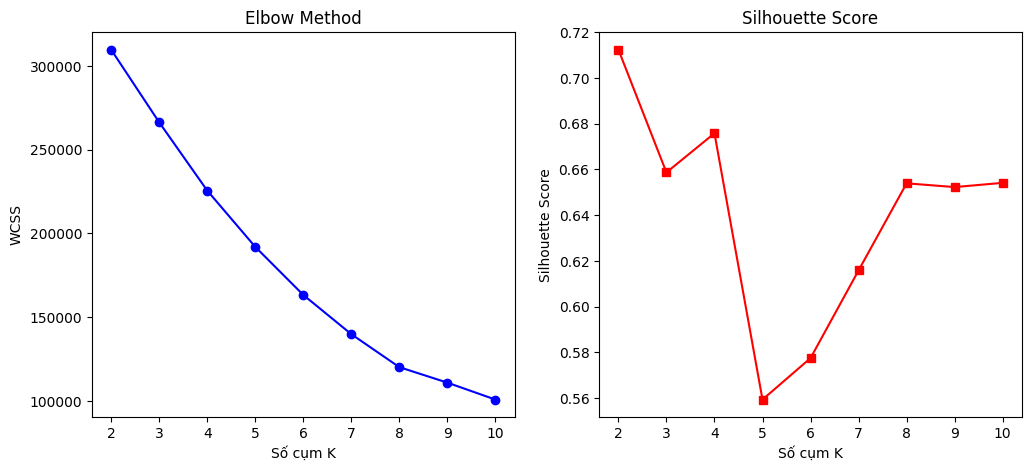

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(2, 11), wcss, marker='o', linestyle='-', color='b')
plt.xlabel("Số cụm K")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='s', linestyle='-', color='r')
plt.xlabel("Số cụm K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()


In [ ]:
optimal_k = 6

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df["Cluster"].value_counts())

Cluster
0    36831
4     5041
3     1660
1     1108
2      536
5      492
Name: count, dtype: int64


In [ ]:
cluster_summary = df.groupby("Cluster")[["Comment_Length", "Engagement_Score", "Món ăn", "Giá cả", "Chất lượng", "Dịch vụ", "Ưu đãi", "Trải nghiệm"]].mean()
print(cluster_summary)

         Comment_Length  Engagement_Score    Món ăn    Giá cả  Chất lượng  \
Cluster                                                                     
0             10.941842       5400.058931  0.152969  0.045044    0.000000   
1             36.917870      11673.360560  0.427798  0.117329    0.077617   
2             46.897388       6276.328358  0.194030  2.662313    0.041045   
3             25.429518       7887.439458  0.287952  0.062048    1.039157   
4             22.066455       5039.873239  0.154930  0.061297    0.000000   
5             19.528455     444835.628049  0.300813  0.073171    0.038618   

          Dịch vụ    Ưu đãi  Trải nghiệm  
Cluster                                   
0        0.000000  0.024002     0.000000  
1        0.216606  0.036101     1.059567  
2        0.251866  2.154851     0.026119  
3        0.125904  0.030723     0.004819  
4        1.403491  0.020829     0.000000  
5        0.103659  0.056911     0.012195  


## biểu đồ phân cụm (PCA / T-SNE)

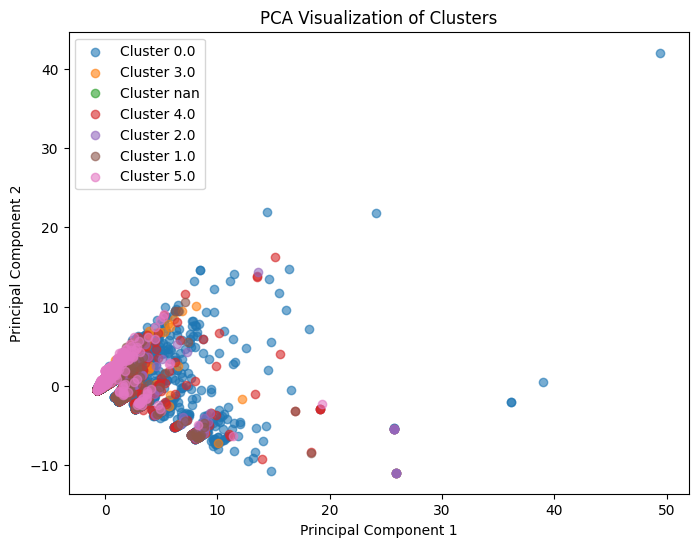

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster']

plt.figure(figsize=(8,6))
for cluster in df_pca['Cluster'].unique():
    subset = df_pca[df_pca['Cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', alpha=0.6)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Clusters')
plt.legend()
plt.show()

#### chọn cluster 2, 5

In [ ]:
print(df.columns)

Index(['postId', 'pageName', 'url', 'time', 'timestamp', 'text', 'likes',
       'comments', 'shares', 'topReactionsCount', 'facebookId_post', 'media',
       'isVideo', 'viewsCount', 'commentUrl', 'commentId', 'date',
       'Comment_Text', 'likesCount', 'log_likes', 'log_comments', 'log_shares',
       'log_topReactionsCount', 'log_viewsCount', 'Engagement_Score', 'month',
       'quarter', 'has_media', 'Comment_Text_Cleaned', 'clean_comment',
       'Món ăn', 'Giá cả', 'Chất lượng', 'Dịch vụ', 'Ưu đãi', 'Trải nghiệm',
       'Comment_Length', 'Cluster'],
      dtype='object')


In [ ]:
df_cluster5 = df[df["Cluster"] == 5]
top_posts_cluster5 = df_cluster5.sort_values(by="Engagement_Score", ascending=False).drop_duplicates(subset=["postId"])
top_posts_cluster5 = top_posts_cluster5[["postId", "text", "url", "likes", "comments", "shares", "Engagement_Score"]]
top_posts_cluster5 = top_posts_cluster5.head(10)
print(top_posts_cluster5)

                 postId                                               text  \
32436  1268284606897858  GIA TỘC DOOKKI - 7 VỊ GIA TRUYỀN\n7 Anh Em, 7 ...   
28719  2971186606484787  DOOKKI - THƯƠNG HIỆU BUFFET TOPPOKKI ĐẦU TIÊN ...   
27846  3035010430102404  [RE-UP] Ở NHÀ XEM PHIM  "GIA TỘC DOOKKI - 7 VỊ...   
5287    529996416438354  Bibimbap tại Dookki, có dễ với Feniu quá hong!...   
39573  2591020651168053  THỨ 7  THẬT TƯƠI ! ĐI ĂN DOOKKI KIẾM  TIỀN "TỶ...   
25446  3183761885227257  DOOKKI VIỆT NAM THÔNG BÁO THAY ĐỔI GIÁ VÉ - TẤ...   
43223  2404012756535511  🥘🥘 LẨU TOPOKKI "GÂY NGHIỆN" ?🥘 😍Fan của ẩm thự...   
27997  3008945709375543  🥘🥘 LẨU TOPOKKI "GÂY NGHIỆN" ?🥘\n 😍Fan của ẩm t...   
14517   336752632429401  ĐÃ CÓ CÔNG THỨC SỐT PANDORA RỒI NÀY FEN ƠI...T...   
18453   225879120183420  Cách trộm cơm " XỊN " tại Dookki Bạn đã thử ch...   

                                                     url  likes  comments  \
32436  https://www.facebook.com/DookkiVietnam/videos/...  43267 

In [ ]:
df_cluster5 = df[df["Cluster"] == 2]
top_posts_cluster2 = df_cluster5.sort_values(by="Engagement_Score", ascending=False).drop_duplicates(subset=["postId"])
top_posts_cluster2 = top_posts_cluster2[["postId", "text", "url", "likes", "comments", "shares", "Engagement_Score"]]
top_posts_cluster2 = top_posts_cluster2.head(10)
print(top_posts_cluster2)

                 postId                                               text  \
25449  3183761885227257  DOOKKI VIỆT NAM THÔNG BÁO THAY ĐỔI GIÁ VÉ - TẤ...   
7549    488254480612548  CÙNG NHÍM VŨ MUKBANG DOOKKIxLIPTON\nPu xuống H...   
34742   311757323414809  👉 Cùng Ninh Dương Lan Ngọc khám phá bên trong ...   
15586   309337785170886  Càn quét Dookki tập 1 với thịt xào kim chi nha...   
31839  2871904876412961  🎉🎉DOOKKI VIỆT NAM GIẢM 50% - MỪNG DOOKKI VIỆT ...   
31778  2919704344976908               Dookki Khuyến mãi 50% trên Toàn Quốc   
34701  2778847499052033  🦀🦐🦑 Thêm vitamin sea chỉ có tại Dookki #HẢI_SẢ...   
35177  2766818460254937  [HCM]🎉 MỪNG LỄ LỚN- DOOKKI VINCOM THỦ ĐỨC GIẢM...   
21691  3408034122800031  Cách để không bị áp lực trong cuộc sống\nTop 1...   
43075  2416441295292657  📣 🎊 10h30 SOFT OPENING DOOKKI TIME CITY HÀ NỘI...   

                                                     url  likes  comments  \
25449  https://www.facebook.com/DookkiVietnam/videos/...   3410 